# Phase 4 — Feature Engineering
**Project:** E-Commerce Customer Behavior ML

| Step | Task |
|---|---|
| 0 | Setup & load cleaned data |
| 1 | User profile features |
| 2 | Session behaviour features |
| 3 | Browse & engagement features |
| 4 | Order history features |
| 5 | Build master feature matrix |
| 6 | Define target variable |
| 7 | Feature selection |
| 8 | Save feature matrix |


## Step 0 — Setup & Load Cleaned Data

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Dynamic paths ─────────────────────────────────────────────────────────────
_cwd          = Path().resolve()
_candidates   = [_cwd / 'data' / 'processed', _cwd.parent / 'data' / 'processed']
PROCESSED_DIR = next((p for p in _candidates if p.exists()), None)

if PROCESSED_DIR is None:
    raise FileNotFoundError("data/processed/ not found — run Phase 2 notebook first.")

PROJECT_ROOT = PROCESSED_DIR.parent.parent
FIGURES_DIR  = PROJECT_ROOT / 'reports' / 'figures'
OUTPUT_DIR   = PROJECT_ROOT / 'data' / 'outputs'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,
                     'axes.spines.right':False,'font.size':11})
sns.set_palette('Set2')

def load(name):
    p = PROCESSED_DIR / f'{name}.parquet'
    return pd.read_parquet(p) if p.exists() else pd.read_csv(PROCESSED_DIR/f'{name}.csv')

users         = load('users')
products      = load('products')
sessions      = load('sessions')
browse_events = load('browse_events')
orders        = load('orders')
order_items   = load('order_items')

# Parse datetimes
sessions['session_start'] = pd.to_datetime(sessions['session_start'])
sessions['session_end']   = pd.to_datetime(sessions['session_end'])
orders['order_date']      = pd.to_datetime(orders['order_date'])
users['signup_date']      = pd.to_datetime(users['signup_date'])

SNAPSHOT = orders['order_date'].max()   # reference date for recency calculations
print(f"Snapshot date (reference): {SNAPSHOT.date()}")
print()
for n,d in [('users',users),('sessions',sessions),
            ('browse_events',browse_events),('orders',orders),('order_items',order_items)]:
    print(f"  {n:<20} {len(d):>8,} rows")

Snapshot date (reference): 2025-05-30

  users                   5,000 rows
  sessions               20,000 rows
  browse_events          89,016 rows
  orders                  8,000 rows
  order_items            23,958 rows


## Step 1 — User Profile Features
Static user attributes from the `users` table. These are already partially encoded
from Phase 2 — we just select and rename for clarity.


In [2]:
# Collect all numeric / encoded user columns dynamically
always_include = ['user_id', 'age', 'account_age_days', 'signup_date']
encoded_cols   = [c for c in users.columns
                  if c in ('membership_encoded', 'is_premium')
                  or c.startswith(('gender_', 'device_'))]

user_features = users[always_include + encoded_cols].copy()

# Age group as ordinal
if 'age_group' in users.columns:
    age_map = {'18-25': 0, '26-35': 1, '36-50': 2, '50+': 3}
    user_features['age_group_enc'] = users['age_group'].map(age_map).fillna(0).astype(int)

# Account tenure buckets
user_features['is_new_user']      = (user_features['account_age_days'] < 30).astype(int)
user_features['is_veteran_user']  = (user_features['account_age_days'] > 365).astype(int)

user_features = user_features.drop(columns=['signup_date'])

print(f"User profile features: {user_features.shape[1]-1} features for {len(user_features):,} users")
print(user_features.drop(columns='user_id').describe().round(2).to_string())

User profile features: 13 features for 5,000 users
            age  account_age_days  membership_encoded  gender_Female  gender_Male  gender_Other  device_desktop  device_mobile  device_tablet  is_premium  age_group_enc  is_new_user  is_veteran_user
count 5000.0000         5000.0000           5000.0000      5000.0000    5000.0000     5000.0000       5000.0000      5000.0000      5000.0000   5000.0000      5000.0000    5000.0000        5000.0000
mean    32.6900          339.1100              0.7200         0.4700       0.4700        0.0600          0.3400         0.5600         0.1000      0.2000         1.1600       0.0500           0.4400
std      9.4800          206.8400              0.9100         0.5000       0.5000        0.2400          0.4800         0.5000         0.3000      0.4000         0.8400       0.2200           0.5000
min     18.0000            0.0000              0.0000         0.0000       0.0000        0.0000          0.0000         0.0000         0.0000      0.0000

## Step 2 — Session Behaviour Features
Aggregate sessions per user to capture their browsing habits, visit frequency,
and recency of activity.


In [3]:
# Numeric session columns to aggregate
num_cols = [c for c in ['duration_secs_clean','pages_visited_clean','engagement_score']
            if c in sessions.columns]

agg_dict = {col: ['mean','max','sum'] for col in num_cols}
agg_dict['session_id']    = 'count'
agg_dict['is_weekend']    = 'mean'

if 'bounced' in sessions.columns:
    agg_dict['bounced'] = 'mean'

sess_agg = sessions.groupby('user_id').agg(agg_dict)
sess_agg.columns = ['_'.join(c).strip('_') for c in sess_agg.columns]
sess_agg = sess_agg.rename(columns={'session_id_count': 'total_sessions'})
sess_agg = sess_agg.reset_index()

# Recency: days since last session
last_session = sessions.groupby('user_id')['session_start'].max().reset_index()
last_session.columns = ['user_id','last_session_date']
last_session['days_since_last_session'] = (SNAPSHOT - last_session['last_session_date']).dt.days
sess_agg = sess_agg.merge(last_session[['user_id','days_since_last_session']], on='user_id', how='left')

# Preferred time bucket (most frequent)
if 'time_bucket' in sessions.columns:
    pref_time = (sessions.groupby('user_id')['time_bucket']
                 .agg(lambda x: x.value_counts().index[0])
                 .reset_index().rename(columns={'time_bucket':'pref_time_bucket'}))
    time_map = {'morning':0,'afternoon':1,'evening':2,'night':3}
    pref_time['pref_time_bucket_enc'] = pref_time['pref_time_bucket'].map(time_map)
    sess_agg = sess_agg.merge(pref_time[['user_id','pref_time_bucket_enc']], on='user_id', how='left')

print(f"Session features: {sess_agg.shape[1]-1} features")
print(sess_agg.drop(columns='user_id').describe().round(3).to_string())

Session features: 14 features
       duration_secs_clean_mean  duration_secs_clean_max  duration_secs_clean_sum  pages_visited_clean_mean  pages_visited_clean_max  pages_visited_clean_sum  engagement_score_mean  engagement_score_max  engagement_score_sum  total_sessions  is_weekend_mean  bounced_mean  days_since_last_session  pref_time_bucket_enc
count                 4465.0000                4465.0000                4465.0000                 4465.0000                4465.0000                4465.0000              4465.0000             4465.0000             4465.0000       4465.0000        4465.0000     4465.0000                4465.0000             4465.0000
mean                   566.4890                1062.5140                2549.6660                    4.6240                   9.1310                  20.6640                 0.3160                0.4740                1.4160          4.4790           0.2830        0.3770                  90.8380                1.7720
std          

## Step 3 — Browse & Engagement Features
From `browse_events` — captures what users click on, how long they spend,
and how likely they are to add things to cart.


In [4]:
# Per-user browse aggregates
browse_agg = browse_events.groupby('user_id').agg(
    total_events            = ('event_id',       'count'),
    unique_products_browsed = ('product_id',     'nunique'),
    avg_time_per_event      = ('time_spent_secs_clean', 'mean'),
    total_time_browsing     = ('time_spent_secs_clean', 'sum'),
    total_cart_adds         = ('added_to_cart',  'sum'),
    total_wishlists         = ('wishlisted',     'sum'),
).reset_index()

# Interaction rates
browse_agg['cart_add_rate'] = (
    browse_agg['total_cart_adds'] /
    browse_agg['total_events'].replace(0, np.nan)
).fillna(0)

browse_agg['wishlist_rate'] = (
    browse_agg['total_wishlists'] /
    browse_agg['total_events'].replace(0, np.nan)
).fillna(0)

# Category diversity — how many unique categories a user has browsed
cat_diversity = (browse_events
    .merge(products[['product_id','category']], on='product_id', how='left')
    .groupby('user_id')['category'].nunique()
    .reset_index().rename(columns={'category':'unique_categories_browsed'}))

browse_agg = browse_agg.merge(cat_diversity, on='user_id', how='left')

# View-to-cart conversion proxy
view_events = browse_events[browse_events['event_type']=='view'].groupby('user_id').size().reset_index(name='total_views')
browse_agg  = browse_agg.merge(view_events, on='user_id', how='left').fillna(0)
browse_agg['view_to_cart_ratio'] = (
    browse_agg['total_cart_adds'] /
    browse_agg['total_views'].replace(0, np.nan)
).fillna(0)

print(f"Browse features: {browse_agg.shape[1]-1} features")
print(browse_agg.drop(columns='user_id').describe().round(3).to_string())

Browse features: 11 features
       total_events  unique_products_browsed  avg_time_per_event  total_time_browsing  total_cart_adds  total_wishlists  cart_add_rate  wishlist_rate  unique_categories_browsed  total_views  view_to_cart_ratio
count     4465.0000                4465.0000           4465.0000            4465.0000        4465.0000        4465.0000      4465.0000      4465.0000                  4465.0000    4465.0000           4465.0000
mean        19.9360                  17.6630            150.4680            3000.1680           2.7920           1.0200         0.1420         0.0520                     4.9060       9.9560              0.2880
std         16.5970                  13.3260             34.5030            2531.4460           2.7990           1.2860         0.1460         0.0880                     1.6090       8.5220              0.3230
min          1.0000                   1.0000              2.0000               2.0000           0.0000           0.0000         0.0

## Step 4 — Order History Features
From `orders` and `order_items` — captures purchase behaviour for users who have
bought. Non-buyers get 0 / NaN filled with 0.


In [5]:
# Per-user order aggregates
order_agg = orders.groupby('user_id').agg(
    total_orders        = ('order_id',      'count'),
    total_spend         = ('total_amount',  'sum'),
    avg_order_value     = ('total_amount',  'mean'),
    max_order_value     = ('total_amount',  'max'),
    avg_discount_pct    = ('discount_pct',  'mean'),
    cancelled_orders    = ('status',        lambda x: (x=='cancelled').sum()),
    returned_orders     = ('status',        lambda x: (x=='returned').sum()),
    last_order_date     = ('order_date',    'max'),
    first_order_date    = ('order_date',    'min'),
).reset_index()

# Derived order features
order_agg['days_since_last_order'] = (SNAPSHOT - order_agg['last_order_date']).dt.days
order_agg['customer_lifespan_days'] = (
    order_agg['last_order_date'] - order_agg['first_order_date']
).dt.days.clip(lower=1)
order_agg['order_frequency']    = (
    order_agg['total_orders'] /
    (order_agg['customer_lifespan_days'] / 30).replace(0, np.nan)
).fillna(order_agg['total_orders'])     # single-order users: freq = order count
order_agg['cancellation_rate']  = (
    order_agg['cancelled_orders'] /
    order_agg['total_orders'].replace(0, np.nan)
).fillna(0)

# Items per order
items_per_order = (order_items.groupby('order_id').agg(
    total_items  = ('quantity','sum'),
    unique_items = ('product_id','nunique')
).reset_index()
.merge(orders[['order_id','user_id']], on='order_id')
.groupby('user_id').agg(
    avg_items_per_order=('total_items','mean'),
    avg_unique_items=('unique_items','mean')
).reset_index())

order_agg = order_agg.merge(items_per_order, on='user_id', how='left')
order_agg = order_agg.drop(columns=['last_order_date','first_order_date'])

print(f"Order features: {order_agg.shape[1]-1} features for {len(order_agg):,} buyers")
print(order_agg.drop(columns='user_id').describe().round(2).to_string())

Order features: 13 features for 2,795 buyers
       total_orders  total_spend  avg_order_value  max_order_value  avg_discount_pct  cancelled_orders  returned_orders  days_since_last_order  customer_lifespan_days  order_frequency  cancellation_rate  avg_items_per_order  avg_unique_items
count     2795.0000    2795.0000        2795.0000        2795.0000         2795.0000         2795.0000        2795.0000              2795.0000               2795.0000        2795.0000          2795.0000            2795.0000         2795.0000
mean         2.8600    2146.7500         750.4200         973.9900            9.4100            0.1500           0.1300               125.2300                108.8100          14.7900             0.0500               7.3900            2.9600
std          2.5400    2049.4600         342.2800         422.9400            7.3400            0.4000           0.3600               102.2900                123.6500          14.6500             0.1700               3.2000      

## Step 5 — Build Master Feature Matrix
Merge all feature groups on `user_id`. Non-buyers will have NaN for order features
— these are filled with 0 (they have spent $0, placed 0 orders, etc.).


In [6]:
feature_matrix = (
    user_features
    .merge(sess_agg,   on='user_id', how='left')
    .merge(browse_agg, on='user_id', how='left')
    .merge(order_agg,  on='user_id', how='left')
)

# Fill NaN — users with no sessions / orders get 0
fill_zero_cols = [c for c in feature_matrix.columns
                  if c != 'user_id' and feature_matrix[c].dtype in ['float64','int64']]
feature_matrix[fill_zero_cols] = feature_matrix[fill_zero_cols].fillna(0)

print(f"Master feature matrix: {feature_matrix.shape[0]:,} users x {feature_matrix.shape[1]-1} features")
print(f"Null values remaining : {feature_matrix.drop(columns='user_id').isnull().sum().sum()}")
print()
print("Feature groups:")
print(f"  User profile    : {user_features.shape[1]-1}")
print(f"  Session         : {sess_agg.shape[1]-1}")
print(f"  Browse          : {browse_agg.shape[1]-1}")
print(f"  Order history   : {order_agg.shape[1]-1}")
print(f"  TOTAL           : {feature_matrix.shape[1]-1}")

Master feature matrix: 5,000 users x 51 features
Null values remaining : 0

Feature groups:
  User profile    : 13
  Session         : 14
  Browse          : 11
  Order history   : 13
  TOTAL           : 51


## Step 6 — Define Target Variable
**Target:** `will_purchase` — binary label indicating whether a user has made
at least one purchase (1) or never purchased (0).

This gives us a classification problem: predict which users are likely to buy.


Target variable: will_purchase
  Buyers (1)     : 2,795  (55.9%)
  Non-buyers (0) : 2,205  (44.1%)
  Imbalance ratio: 1 : 0.8

>> Class imbalance detected — use class_weight='balanced'
   or SMOTE oversampling in Phase 5 (modeling).


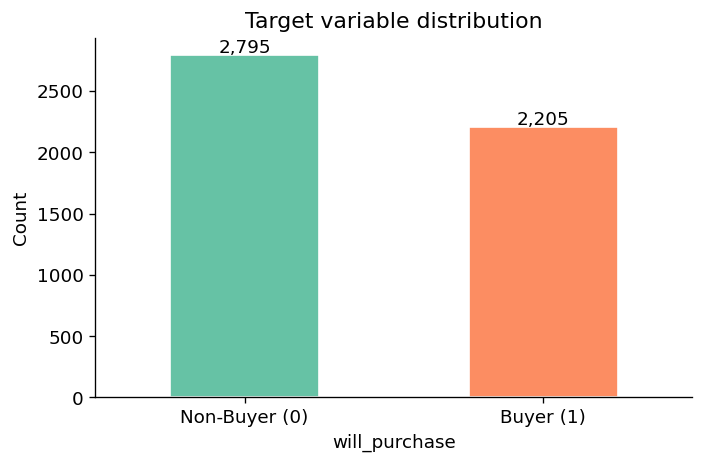

In [7]:
buyer_ids = set(orders['user_id'])
feature_matrix['will_purchase'] = feature_matrix['user_id'].isin(buyer_ids).astype(int)

n_buyers     = feature_matrix['will_purchase'].sum()
n_total      = len(feature_matrix)
buyer_pct    = 100 * n_buyers / n_total

print(f"Target variable: will_purchase")
print(f"  Buyers (1)     : {n_buyers:,}  ({buyer_pct:.1f}%)")
print(f"  Non-buyers (0) : {n_total-n_buyers:,}  ({100-buyer_pct:.1f}%)")
print(f"  Imbalance ratio: 1 : {(n_total-n_buyers)/n_buyers:.1f}")
print()
print(">> Class imbalance detected — use class_weight='balanced'")
print("   or SMOTE oversampling in Phase 5 (modeling).")

fig, ax = plt.subplots(figsize=(6, 4))
feature_matrix['will_purchase'].value_counts().plot(
    kind='bar', ax=ax, edgecolor='white',
    color=[sns.color_palette('Set2')[0], sns.color_palette('Set2')[1]])
ax.set_xticklabels(['Non-Buyer (0)','Buyer (1)'], rotation=0)
ax.set_title('Target variable distribution')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()+20),
                ha='center', fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_target_distribution.png', bbox_inches='tight')
plt.show()

## Step 7 — Feature Selection
Remove features that are:
1. **Constant** — zero variance, carry no signal
2. **Highly correlated** (|r| > 0.95) — redundant, cause multicollinearity
3. **Leakage risks** — columns that directly encode the target


In [8]:
from sklearn.feature_selection import VarianceThreshold

feature_cols = [c for c in feature_matrix.columns if c not in ('user_id','will_purchase')]
X = feature_matrix[feature_cols]

# 1. Remove zero-variance features
vt      = VarianceThreshold(threshold=0)
vt.fit(X)
low_var = [c for c, keep in zip(feature_cols, vt.get_support()) if not keep]
print(f"Zero-variance features removed: {len(low_var)}  {low_var}")
X = X[vt.get_feature_names_out().tolist()]

# 2. Remove highly correlated pairs (|r| > 0.95)
corr_matrix  = X.corr().abs()
upper_tri    = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
drop_corr    = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)]
print(f"High-correlation features removed (|r|>0.95): {len(drop_corr)}  {drop_corr}")
X = X.drop(columns=drop_corr)

# 3. Leakage check — remove any column that directly relates to orders for non-buyers
#    (already handled — non-buyers have 0 for all order features)
print(f"\nFinal feature count : {X.shape[1]}")
print(f"Final feature list  :\n  {list(X.columns)}")

Zero-variance features removed: 0  []
High-correlation features removed (|r|>0.95): 6  ['total_sessions', 'unique_products_browsed', 'total_time_browsing', 'total_views', 'total_spend', 'avg_unique_items']

Final feature count : 45
Final feature list  :
  ['age', 'account_age_days', 'membership_encoded', 'gender_Female', 'gender_Male', 'gender_Other', 'device_desktop', 'device_mobile', 'device_tablet', 'is_premium', 'age_group_enc', 'is_new_user', 'is_veteran_user', 'duration_secs_clean_mean', 'duration_secs_clean_max', 'duration_secs_clean_sum', 'pages_visited_clean_mean', 'pages_visited_clean_max', 'pages_visited_clean_sum', 'engagement_score_mean', 'engagement_score_max', 'engagement_score_sum', 'is_weekend_mean', 'bounced_mean', 'days_since_last_session', 'pref_time_bucket_enc', 'total_events', 'avg_time_per_event', 'total_cart_adds', 'total_wishlists', 'cart_add_rate', 'wishlist_rate', 'unique_categories_browsed', 'view_to_cart_ratio', 'total_orders', 'avg_order_value', 'max_order

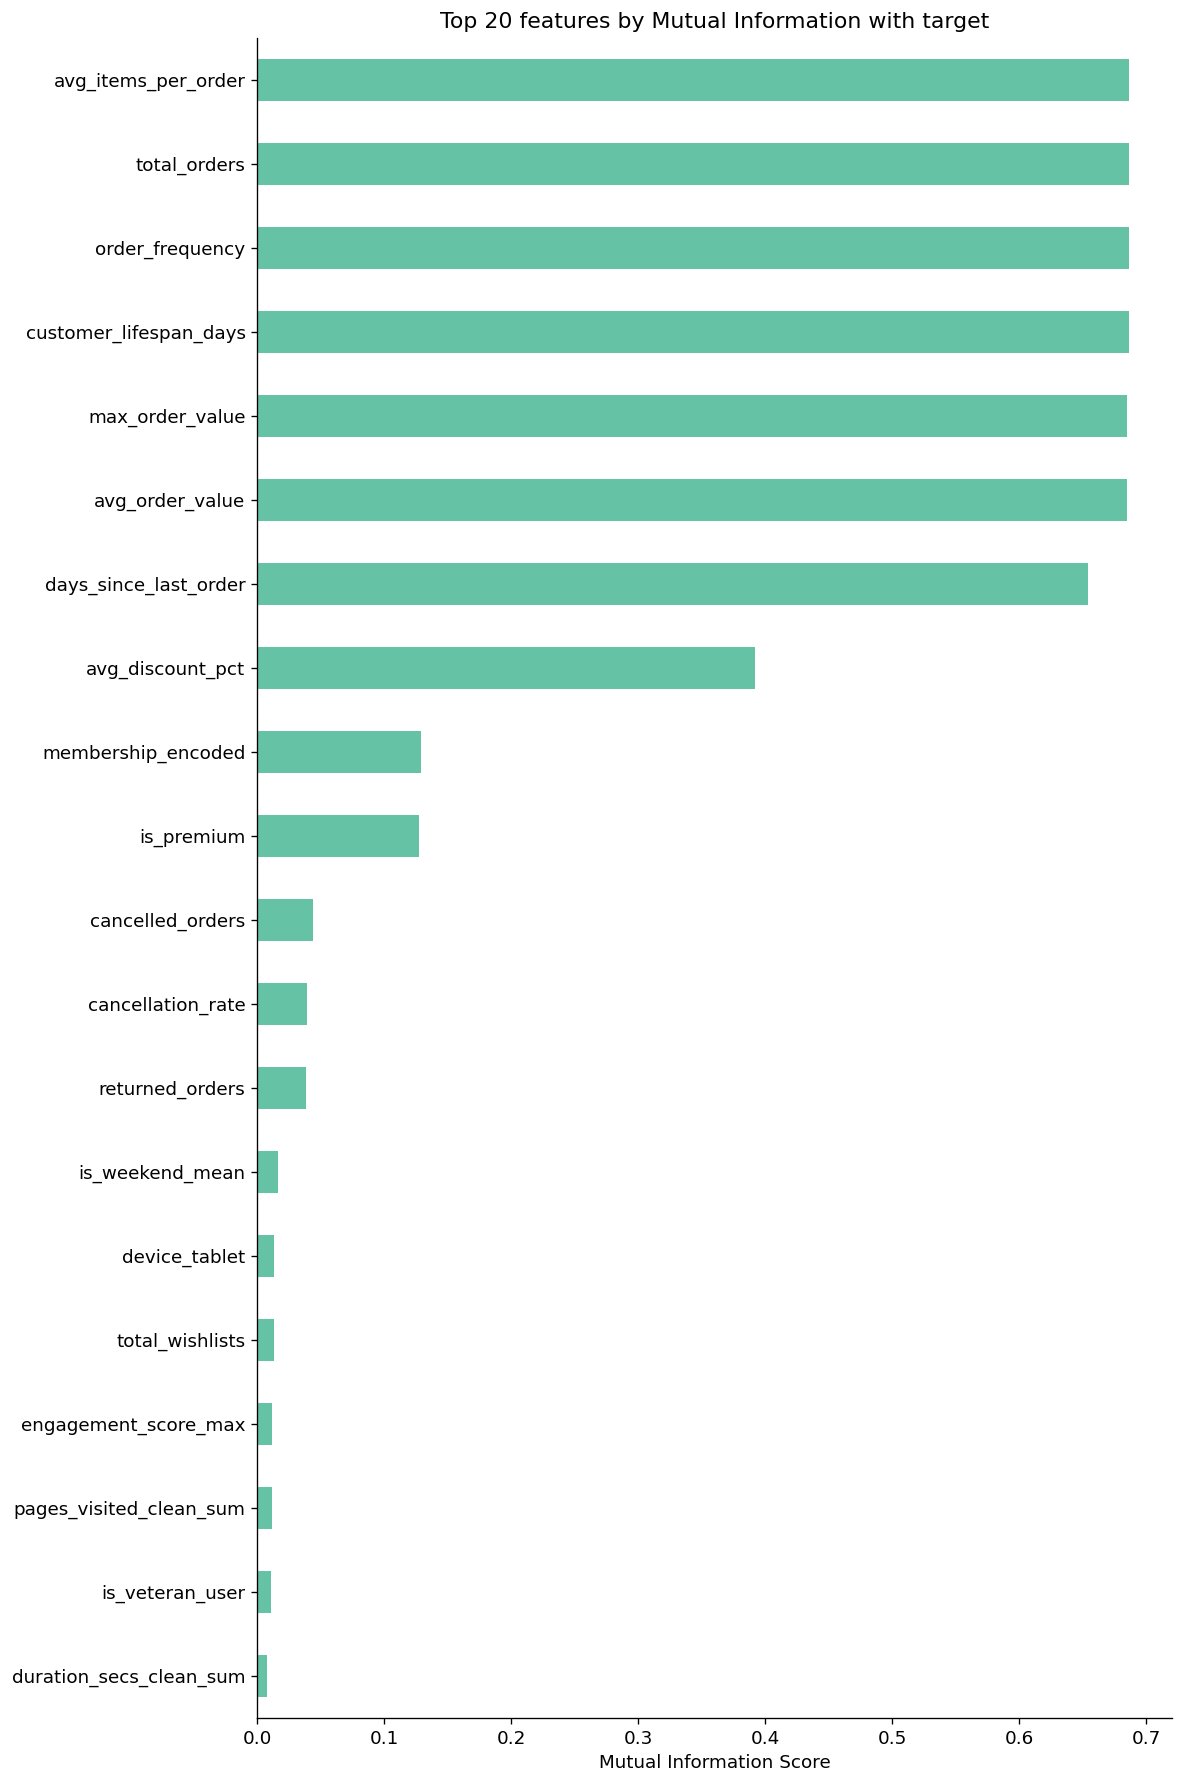

Top 10 most predictive features:
avg_items_per_order      0.6864
total_orders             0.6864
order_frequency          0.6864
customer_lifespan_days   0.6863
max_order_value          0.6849
avg_order_value          0.6849
days_since_last_order    0.6541
avg_discount_pct         0.3919
membership_encoded       0.1290
is_premium               0.1276


In [9]:
# Feature importance preview using mutual information
from sklearn.feature_selection import mutual_info_classif

y  = feature_matrix['will_purchase']
mi = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, max(5, len(mi_series)//3)))
mi_series.head(20).sort_values().plot(kind='barh', ax=ax, color=sns.color_palette('Set2')[0])
ax.set_title('Top 20 features by Mutual Information with target')
ax.set_xlabel('Mutual Information Score')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_feature_importance.png', bbox_inches='tight')
plt.show()
print("Top 10 most predictive features:")
print(mi_series.head(10).round(4).to_string())

## Step 8 — Save Feature Matrix

In [10]:
# Final feature matrix: X (features) + y (target) + user_id
final_df = pd.concat([feature_matrix[['user_id']], X, y], axis=1)

def save_df(df, name, out_dir):
    try:
        path = out_dir / f'{name}.parquet'
        df.to_parquet(path, index=False)
    except Exception:
        path = out_dir / f'{name}.csv'
        df.to_csv(path, index=False)
    return path

# Save to processed/ (used by Phase 5)
path = save_df(final_df, 'feature_matrix', PROCESSED_DIR)
print(f"Feature matrix saved → {path}")
print(f"Shape: {final_df.shape[0]:,} rows x {final_df.shape[1]} columns")
print(f"  Features : {X.shape[1]}")
print(f"  Target   : will_purchase  (1=buyer, 0=non-buyer)")

# Also save feature names list for Phase 5
feat_names = X.columns.tolist()
feat_path  = OUTPUT_DIR / 'feature_names.txt'
feat_path.write_text('\n'.join(feat_names))
print(f"Feature names saved → {feat_path}")

# Summary
print(f"\n{'='*55}")
print(f"  Phase 4 complete")
print(f"  {X.shape[1]} features engineered for {len(final_df):,} users")
print(f"  Buyers: {y.sum():,}  |  Non-buyers: {(y==0).sum():,}")
print(f"{'='*55}")

Feature matrix saved → C:\Users\ATUL\Desktop\BIT BOY\ECOMMERCE_CUSTOMER_BEHAVIOR\data\processed\feature_matrix.parquet
Shape: 5,000 rows x 47 columns
  Features : 45
  Target   : will_purchase  (1=buyer, 0=non-buyer)
Feature names saved → C:\Users\ATUL\Desktop\BIT BOY\ECOMMERCE_CUSTOMER_BEHAVIOR\data\outputs\feature_names.txt

  Phase 4 complete
  45 features engineered for 5,000 users
  Buyers: 2,795  |  Non-buyers: 2,205


## ✅ Phase 4 Complete

### Feature groups built
| Group | Source | Features |
|---|---|---|
| User profile | `users` | age, membership, device, premium flag, tenure |
| Session behaviour | `sessions` | total sessions, avg duration, bounce rate, recency, time bucket |
| Browse & engagement | `browse_events` | cart rate, wishlist rate, category diversity, view-to-cart ratio |
| Order history | `orders` + `order_items` | total orders, spend, frequency, cancellation rate, avg basket |

### ⏭️ Phase 5 — Modeling
Open `05_modeling.ipynb` — train & tune LightGBM, XGBoost, and Logistic Regression
on the feature matrix, handle class imbalance, and pick the best model.
